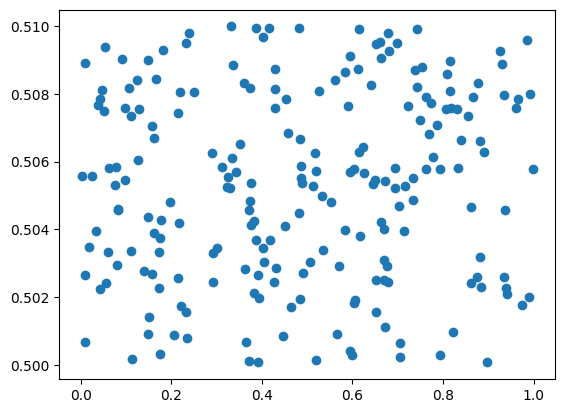

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def randu(start, N_samples):
  pseudo_random_sequence = np.zeros(N_samples, dtype=int)
  pseudo_random_sequence[0] = start
  cst = 2**31
  for i in range(1, N_samples):
    pseudo_random_sequence[i] = (65539 * pseudo_random_sequence[i-1]) % cst
  return pseudo_random_sequence / cst

my_sequence = randu(1, 2*10**4)
idx_of_interest = np.argwhere((my_sequence >=0.5)*(my_sequence<=0.51))
plt.scatter(my_sequence[idx_of_interest -1 ], my_sequence[idx_of_interest])

plt.show()

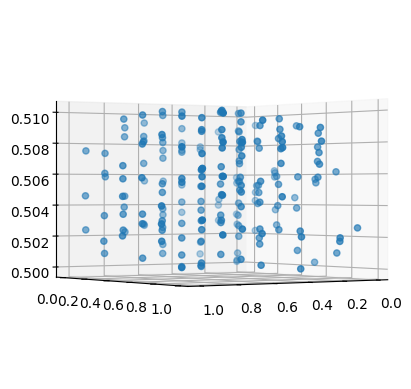

In [ ]:
for view in [55]:
  fig = plt.figure()
  ax = fig.add_subplot(111, projection="3d")
  ax.view_init(0, view)
  ax.scatter(my_sequence[idx_of_interest-2],my_sequence[idx_of_interest-1], my_sequence[idx_of_interest] )
  plt.show()

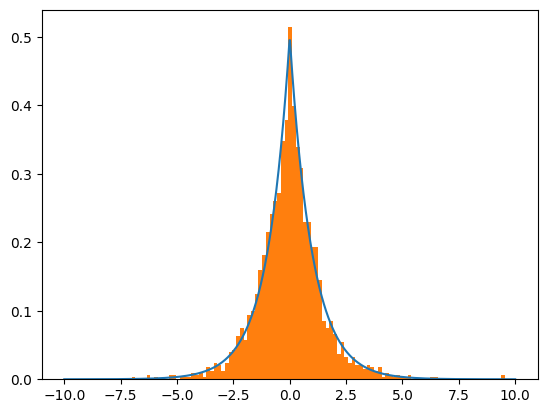

In [ ]:
def sample_laplace(seed, N_samples):
  np.random.seed(seed)
  my_signs = 1-2*np.random.binomial(1, 0.5, size=(N_samples,))
  my_uniforms = np.random.uniform(size=(N_samples,))
  my_exponentials = -np.log(my_uniforms)
  return my_exponentials * my_signs

seed = 0
my_laplace_samples = sample_laplace(seed, 2000)

pdf_laplace = lambda x: 0.5*np.exp(-np.abs(x))

x_range = np.linspace(-10, 10, 1000)

plt.plot(x_range, pdf_laplace(x_range))
plt.hist(my_laplace_samples, density=True, bins=100)

plt.show()

In [ ]:
"""
See Ex. 8.2 of N. Chopin, O. Papaspilliopoulos:
The acceptance rate of the Algorithm is 1 / M where
M is the chosen upper bound of f/g, with f, the pdf of the Laplace distribution
and g is the pdf of the Gaussian distribution.
In that case, the best M is sqrt(2 * exp(1) / pi) which is approximately 1.3154892469584106
Thus the acceptance rate is 76%
"""
(np.sqrt(np.pi/2)*np.exp(-1/2))

np.float64(0.7601734505331403)

In [ ]:
import scipy
pdf_gaussian = lambda x: scipy.stats.norm.pdf(x)
def reject_sampling(seed, N_try_max):
  M = 1/(np.sqrt(np.pi/2)*np.exp(-1/2))
  count = 0
  while count < N_try_max:
    count +=1
    U = np.random.uniform()
    X = sample_laplace(seed, 1)[0]
    if U < pdf_gaussian(X)/pdf_laplace(X) * 1/M:
      return X, count
  return "fail", None

my_sample, T_before_accept = reject_sampling(0, 100)

n_try = 1000
count_accept_in_1 = 0
for i in range(n_try):
  _, t = reject_sampling(i, 100)
  if t == 1:
    count_accept_in_1 += 1
print(count_accept_in_1/n_try)

0.775
